In [16]:
import pandas as pd
import numpy as np
data = pd.read_csv("content/Data.csv")

data = data.drop(columns=["VD", "VE", "tempo"])

data.index = (np.arange(0, len(data), 1).astype(float) * 0.07).round(5)

data = data.rename(columns={
    "Setpoint VD": "Wd",
    "Setpoint VE": "We",
    "Theta": "theta(Wd,We)",
    "X": "x(Wd,We)",
    "Y": "y(Wd,We)",
})

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from keras import layers, models, regularizers
from keras.callbacks import EarlyStopping

# Define predictors and target
PREDICTORS = ["Wd", "We"]
TARGET = "theta(Wd,We)"

class EvalSmallSizeProblem:
    def __init__(self, Dataset):
        self.df = Dataset.copy()
        self.scaler = StandardScaler()
        self.df[PREDICTORS] = self.scaler.fit_transform(self.df[PREDICTORS])
        self.mse_results = []  
        
    def GetData(self, size=32):
        df = self.df.head(size)

        # Split into train (70%), validation (30%)
        train_data, valid_data = train_test_split(df, test_size=0.3, shuffle=False)
        
        self.train_x = train_data[PREDICTORS].to_numpy()
        self.train_y = train_data[[TARGET]].to_numpy()

        self.val_x = valid_data[PREDICTORS].to_numpy()
        self.val_y = valid_data[[TARGET]].to_numpy()
    
    def CompileModel(self, model, epochs=100):
        model.compile(loss="mse", optimizer="adam")

        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        history = model.fit(
            self.train_x, self.train_y,
            epochs=epochs,
            validation_data=(self.val_x, self.val_y),
            callbacks=[early_stop],
            verbose=False
        )
        
        return history.history['val_loss'][-1]  # Retorna o último MSE da validação

    def Evaluate(self):
        DatasetSize = len(self.df)
        percentages = np.arange(0.001, 0.5, 0.05)
        self.num_samples = [int(DatasetSize * p) for p in percentages]
                
        for size in self.num_samples:   
            self.GetData(size=size)    
            model = models.Sequential([
                layers.Input(shape=(2, 1)),
                layers.SimpleRNN(
                    5,
                    return_sequences=False,
                    kernel_regularizer=regularizers.l2(0.01)
                ),
                layers.Dense(1, kernel_regularizer=regularizers.l2(0.01))
            ])
            mse_values = []
            for i in range(500):
                print(f"---- {size}:{i} -----")
                self.CompileModel(model, epochs=100)
                self.GetData(size=DatasetSize)    
                mse_sup = model.evaluate(self.train_x, self.train_y)
                mse_values.append(mse_sup)
            self.mse_results.append(np.array(mse_values))   

In [56]:
problem = EvalSmallSizeProblem(data)
problem.Evaluate()

---- 214:0 -----
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1080 
---- 214:1 -----
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0641 
---- 429:0 -----
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1923 
---- 429:1 -----
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1400 
---- 643:0 -----
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1189 
---- 643:1 -----
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0764
---- 858:0 -----
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0982 
---- 858:1 -----
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0658 


In [57]:
problem.mse_results

[array([0.11424023, 0.07063247]),
 array([0.23421213, 0.16089419]),
 array([0.13310246, 0.08113991]),
 array([0.13148975, 0.07239069])]

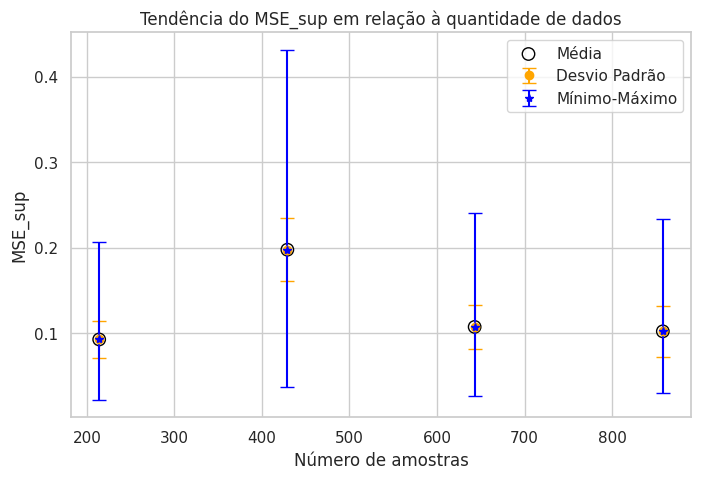

In [ ]:


def PlotMSE(mse_results, num_samples, img_name="mse_plot.png"):
    mse_results = np.array(mse_results)  # Converter lista de arrays para matriz (N, 2)

    # Calcular estatísticas corretamente
    mse_mean = np.mean(mse_results, axis=1)
    mse_std = np.std(mse_results, axis=1)
    mse_min = np.min(mse_results, axis=1)
    mse_max = np.max(mse_results, axis=1)

    # Estilo
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(8, 5))

    # Gráfico de erro padrão com traços nos extremos
    plt.errorbar(num_samples, mse_mean, yerr=mse_std, fmt="o", label="Desvio Padrão", color="orange", capsize=5)
    
    # Gráfico de faixa Min-Max com traços nos extremos
    plt.errorbar(num_samples, mse_mean, yerr=[mse_min, mse_max], fmt="*", label="Mínimo-Máximo", color="blue", capsize=5)
    
    # Média dos valores com marcadores vazados
    plt.scatter(num_samples, mse_mean, label="Média", edgecolors="black", facecolors="none", s=80)

    plt.xlabel("Número de amostras")
    plt.ylabel("MSE_sup")
    plt.title("Tendência do MSE_sup em relação à quantidade de dados")
    plt.legend()
    
    plt.savefig(f"content/{img_name}", format="png", dpi=300)
    plt.show()


PlotMSE(problem.mse_results, problem.num_samples)


In [ ]:
import plotly.offline as py
import plotly.graph_objs as go
import plotly.figure_factory as ff
from scipy.spatial import Delaunay

# Função para plotar a superfície X, Y, Z, mesh_x=32, mesh_y=32
def PlotSurface(data):
    x_sup, y_sup, z_sup = data['Wd'], data['We'], data['theta(Wd,We)']

    points = np.column_stack((x_sup, y_sup))
    tri = Delaunay(points)

    # Criar a superfície original
    fig_surface = ff.create_trisurf(x=x_sup, y=y_sup, z=z_sup, simplices=tri.simplices, colormap='Greys')

    virtual_surface = go.Surface(
     

    # Criar a figura com uma única cena
    fig = go.Figure()


    # Adicionar a superfície original como uma superfície
    fig.add_trace(fig_surface.data[0])

    # Adicionar a superfície virtual
    fig.add_trace(virtual_surface)
    
    # Atualizar o layout
    fig.update_layout(
        title=f'Surface fit',
        scene=dict(
            xaxis_title='Wd',
            yaxis_title='We',
            zaxis_title='theta(Wd,We)',
            aspectmode='cube',
            xaxis = dict(backgroundcolor = "white"),
            yaxis = dict(backgroundcolor = "white"),
            zaxis = dict(backgroundcolor = "white"),

        )
    )
    py.iplot(fig)

In [17]:
PlotSurface(data)

/home/codespace/.local/lib/python3.12/site-packages/plotly/figure_factory/_trisurf.py:171: FutureWarning:

The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead

/home/codespace/.local/lib/python3.12/site-packages/plotly/figure_factory/_trisurf.py:172: FutureWarning:

The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead

/home/codespace/.local/lib/python3.12/site-packages/plotly/figure_factory/_trisurf.py:173: FutureWarning:

The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead

